# Диагностика и классификация неисправностей по сигналам датчиков

**Курс:** Интеллектуальные измерительные системы

**Задача:** по сигналам вибрации и тока электродвигателя определить
техническое состояние оборудования: норма или один из видов неисправности.

Используются **синтетические сигналы**, имитирующие показания датчика
вибрации (акселерометра) и датчика тока, для четырёх состояний:

1. **Норма** — исправный двигатель
2. **Дисбаланс ротора** — повышенная амплитуда на оборотной частоте
3. **Дефект подшипника** — высокочастотные импульсные составляющие
4. **Несоосность (misalignment)** — выраженные 2-я и 3-я гармоники оборотной частоты

Пайплайн: генерация сигналов → извлечение признаков (временная и частотная
область) → обучение классификатора → оценка качества → диагностика на
новом сигнале.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 123
rng = np.random.default_rng(SEED)

FS = 5000          # sampling frequency, Hz
DURATION = 1.0      # signal duration, s
T = np.arange(0, DURATION, 1 / FS)
F_ROT = 25.0         # motor rotational frequency, Hz (1500 rpm)


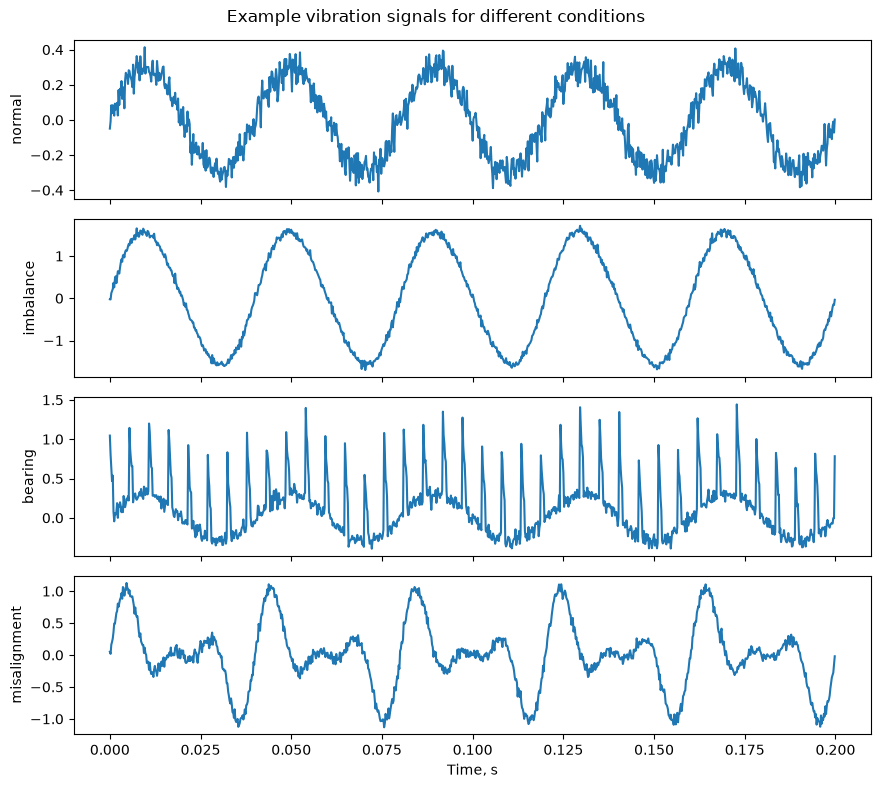

In [2]:
def generate_signal(fault_type, rng):
    """Generate a pair of signals (vibration, current) for the given condition type."""
    noise_v = 0.05 * rng.standard_normal(len(T))
    noise_i = 0.03 * rng.standard_normal(len(T))

    if fault_type == 'normal':
        vib = 0.3 * np.sin(2 * np.pi * F_ROT * T) + noise_v
        cur = 1.0 * np.sin(2 * np.pi * 50 * T) + noise_i

    elif fault_type == 'imbalance':
        # amplitude increase at the rotational frequency
        amp = rng.uniform(1.2, 1.6)
        vib = amp * np.sin(2 * np.pi * F_ROT * T) + 0.1 * np.sin(2 * np.pi * 50 * T) + noise_v
        cur = 1.0 * np.sin(2 * np.pi * 50 * T) + 0.08 * np.sin(2 * np.pi * F_ROT * T) + noise_i

    elif fault_type == 'bearing':
        # high-frequency impulses (impacts) on top of the baseline vibration
        vib = 0.3 * np.sin(2 * np.pi * F_ROT * T) + noise_v
        impact_freq = 180.0  # bearing fault frequency, Hz
        impacts = np.zeros(len(T))
        period_samples = int(FS / impact_freq)
        for start in range(0, len(T), period_samples):
            width = 5
            end = min(start + width, len(T))
            impacts[start:end] += rng.uniform(0.8, 1.4)
        envelope = np.exp(-((np.arange(len(T)) % period_samples) / (period_samples * 0.15)))
        vib += 0.9 * impacts * envelope
        cur = 1.0 * np.sin(2 * np.pi * 50 * T) + noise_i

    elif fault_type == 'misalignment':
        # pronounced 2nd and 3rd harmonics of the rotational frequency
        vib = (0.3 * np.sin(2 * np.pi * F_ROT * T)
               + 0.55 * np.sin(2 * np.pi * 2 * F_ROT * T)
               + 0.35 * np.sin(2 * np.pi * 3 * F_ROT * T)
               + noise_v)
        cur = 1.0 * np.sin(2 * np.pi * 50 * T) + 0.1 * np.sin(2 * np.pi * 2 * F_ROT * T) + noise_i

    else:
        raise ValueError(fault_type)

    return vib, cur


fault_types = ['normal', 'imbalance', 'bearing', 'misalignment']

fig, axes = plt.subplots(len(fault_types), 1, figsize=(9, 8), sharex=True)
for ax, ft in zip(axes, fault_types):
    vib, _ = generate_signal(ft, rng)
    ax.plot(T[:1000], vib[:1000])
    ax.set_ylabel(ft)
axes[-1].set_xlabel('Time, s')
fig.suptitle('Example vibration signals for different conditions')
plt.tight_layout()
plt.show()


In [3]:
def extract_features(vib, cur):
    feats = {}
    for name, sig in [('vib', vib), ('cur', cur)]:
        feats[f'{name}_rms'] = np.sqrt(np.mean(sig ** 2))
        feats[f'{name}_std'] = np.std(sig)
        feats[f'{name}_peak'] = np.max(np.abs(sig))
        feats[f'{name}_crest'] = feats[f'{name}_peak'] / (feats[f'{name}_rms'] + 1e-9)

        spectrum = np.abs(rfft(sig))
        freqs = rfftfreq(len(sig), d=1 / FS)
        feats[f'{name}_dom_freq'] = freqs[np.argmax(spectrum)]
        feats[f'{name}_spec_energy'] = np.sum(spectrum ** 2)

        # high-frequency band energy (characteristic of bearing faults)
        hf_mask = freqs > 150
        feats[f'{name}_hf_energy_ratio'] = (
            np.sum(spectrum[hf_mask] ** 2) / (np.sum(spectrum ** 2) + 1e-9)
        )
    return feats


n_samples_per_class = 120
rows = []
for ft in fault_types:
    for _ in range(n_samples_per_class):
        vib, cur = generate_signal(ft, rng)
        feats = extract_features(vib, cur)
        feats['label'] = ft
        rows.append(feats)

df = pd.DataFrame(rows)
print(df.shape)
df.head()


(480, 15)


,vib_rms,vib_std,vib_peak,vib_crest,vib_dom_freq,vib_spec_energy,vib_hf_energy_ratio,cur_rms,cur_std,cur_peak,cur_crest,cur_dom_freq,cur_spec_energy,cur_hf_energy_ratio,label
0,0.217633,0.217632,0.452320,2.078357,25.0,592059.834852,0.049159,0.708121,0.708121,1.087527,1.535793,50.0,6.267944e+06,0.001660,normal
1,0.218707,0.218705,0.463306,2.118392,25.0,597923.816582,0.048165,0.707919,0.707918,1.082533,1.529178,50.0,6.264373e+06,0.001713,normal
2,0.218196,0.218195,0.485372,2.224481,25.0,595161.554392,0.050586,0.707613,0.707612,1.084087,1.532034,50.0,6.258954e+06,0.001674,normal
3,0.217758,0.217757,0.474828,2.180535,25.0,592741.830772,0.049649,0.707778,0.707777,1.094162,1.545913,50.0,6.261869e+06,0.001664,normal
4,0.217495,0.217495,0.464040,2.133564,25.0,591305.388755,0.049289,0.708286,0.708285,1.084330,1.530922,50.0,6.270874e+06,0.001714,normal


In [4]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=SEED)
clf.fit(X_train_scaled, y_train)

preds = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, preds)
print('Accuracy:', round(acc, 4))
print(classification_report(y_test, preds))


Accuracy: 1.0
              precision    recall  f1-score   support

     bearing       1.00      1.00      1.00        30
   imbalance       1.00      1.00      1.00        30
misalignment       1.00      1.00      1.00        30
      normal       1.00      1.00      1.00        30

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



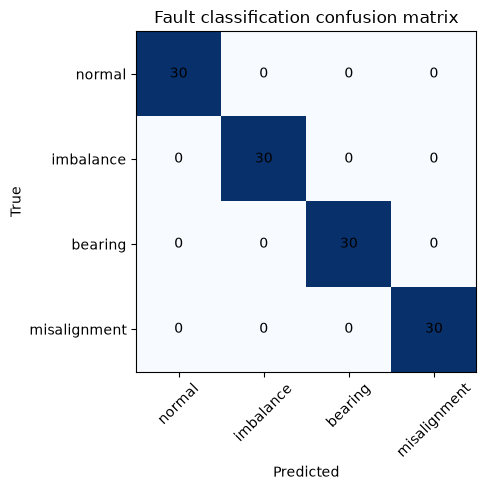

In [5]:
labels_order = fault_types
cm = confusion_matrix(y_test, preds, labels=labels_order)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels_order))); ax.set_xticklabels(labels_order, rotation=45)
ax.set_yticks(range(len(labels_order))); ax.set_yticklabels(labels_order)
for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Fault classification confusion matrix')
plt.tight_layout()
plt.show()


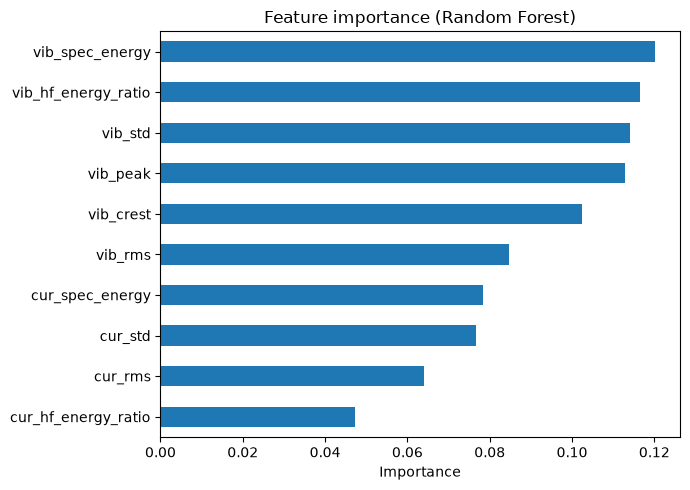

vib_spec_energy        0.120218
vib_hf_energy_ratio    0.116619
vib_std                0.114057
vib_peak               0.112931
vib_crest              0.102312
vib_rms                0.084642
cur_spec_energy        0.078428
cur_std                0.076647
cur_rms                0.064086
cur_hf_energy_ratio    0.047157
dtype: float64


In [6]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.head(10))


In [7]:
# Diagnose a new, previously unseen signal
test_fault = 'bearing'
vib_new, cur_new = generate_signal(test_fault, np.random.default_rng(SEED + 1))
feats_new = pd.DataFrame([extract_features(vib_new, cur_new)])
feats_new_scaled = scaler.transform(feats_new)

predicted_state = clf.predict(feats_new_scaled)[0]
probs = clf.predict_proba(feats_new_scaled)[0]

print('True condition:', test_fault)
print('Predicted condition:', predicted_state)
for cls, p in zip(clf.classes_, probs):
    print(f'  P({cls}) = {p:.3f}')


True condition: bearing
Predicted condition: bearing
  P(bearing) = 1.000
  P(imbalance) = 0.000
  P(misalignment) = 0.000
  P(normal) = 0.000


## Вывод

Признаки временной области (RMS, эксцесс, крест-фактор) и частотной области
(доминирующая частота, доля высокочастотной энергии) в сочетании со
случайным лесом позволяют надёжно различать норму и три типа неисправностей
(дисбаланс, дефект подшипника, несоосность) по синтетическим сигналам
вибрации и тока. Наибольшую информативность показали признаки, связанные с
эксцессом и высокочастотной энергией вибрации — что согласуется с физикой
дефекта подшипника (импульсные удары) — и амплитудные признаки вибрации для
дисбаланса/несоосности.

В реальной измерительной системе тот же пайплайн (извлечение признаков →
классификатор) применяется к сигналам, полученным с реальных датчиков
вибрации и тока электродвигателя.
